Loaded 4317 images across 5 classes
Feature matrix shape: (4317, 384)
KNN Accuracy (Mean+Max+Min pooling): 0.4317
              precision    recall  f1-score   support

       daisy       0.32      0.45      0.37       153
   dandelion       0.50      0.67      0.57       210
        rose       0.39      0.36      0.37       157
   sunflower       0.57      0.36      0.44       147
       tulip       0.42      0.27      0.33       197

    accuracy                           0.43       864
   macro avg       0.44      0.42      0.42       864
weighted avg       0.44      0.43      0.42       864



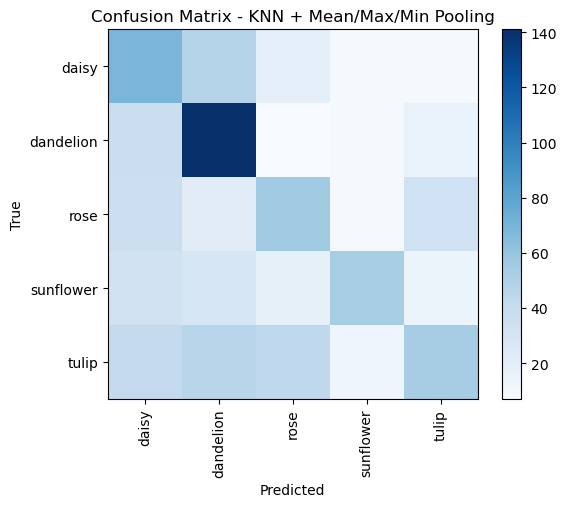

In [1]:
import os
import glob
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
DATA_DIR = "flowers"  # dataset: data/<class>/*.jpg
MAX_SIZE = 400
RANDOM_STATE = 42
TEST_SIZE = 0.2
KNN_NEIGHBORS = 3
# ---------------------

def preprocess_image(img, max_size=400):
    """Resize, grayscale, denoise, and enhance contrast for SIFT."""
    h, w = img.shape[:2]
    scale = max_size / max(h, w)
    if scale < 1.0:
        img = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)
    return gray

def load_dataset(data_dir):
    images = []
    labels = []
    classes = sorted(os.listdir(data_dir))
    for idx, cls in enumerate(classes):
        for file in glob.glob(os.path.join(data_dir, cls, '*')):
            img = cv2.imread(file)
            if img is not None:
                images.append(img)
                labels.append(idx)
    return images, np.array(labels), classes

# Load dataset
images, labels, classes = load_dataset(DATA_DIR)
print(f"Loaded {len(images)} images across {len(classes)} classes")

# Create SIFT detector
sift = cv2.SIFT_create()
mean_pools =[]
max_pools =[]
min_pools =[]

# Feature extraction with pooling
features = []
for img in images:
    gray = preprocess_image(img, MAX_SIZE)
    kp, desc = sift.detectAndCompute(gray, None)

    if desc is None or len(desc) == 0:
        # No keypoints -> zero vector
        mean_pool = np.zeros(128)
        max_pool = np.zeros(128)
        min_pool = np.zeros(128)
    else:
        mean_pool = np.mean(desc, axis=0)
        max_pool = np.max(desc, axis=0)
        min_pool = np.min(desc, axis=0)

    # Combine pools (Mean + Max + Min)
    pooled = np.concatenate([mean_pool, max_pool, min_pool])
    max_pools.append(max_pool)
    mean_pools.append(mean_pool)
    min_pools.append(min_pool)

    features.append(pooled)

features = np.array(features, dtype=np.float32)
print("Feature matrix shape:", features.shape)

# Normalize features (optional but helps distance metrics)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, labels, test_size=TEST_SIZE, stratify=labels, random_state=RANDOM_STATE
)

# KNN classifier
knn = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS, metric='euclidean')
knn.fit(X_train, y_train)

# Evaluate
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy (Mean+Max+Min pooling): {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - KNN + Mean/Max/Min Pooling")
plt.colorbar()
plt.xticks(np.arange(len(classes)), classes, rotation=90)
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Feature matrix shape: (4317, 128)
KNN Accuracy (Mean+Max+Min pooling): 0.3322
              precision    recall  f1-score   support

       daisy       0.25      0.34      0.29       153
   dandelion       0.37      0.60      0.45       210
        rose       0.44      0.24      0.31       157
   sunflower       0.35      0.24      0.29       147
       tulip       0.29      0.18      0.22       197

    accuracy                           0.33       864
   macro avg       0.34      0.32      0.31       864
weighted avg       0.34      0.33      0.32       864



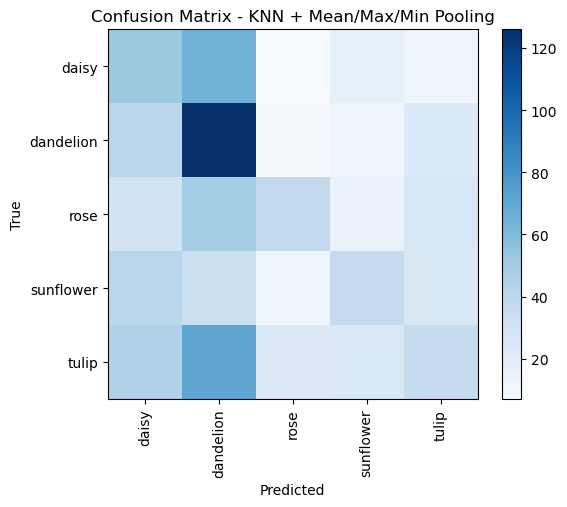

In [2]:
# using max pooling only
features = np.array(max_pools, dtype=np.float32)
print("Feature matrix shape:", features.shape)

# Normalize features (optional but helps distance metrics)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, labels, test_size=TEST_SIZE, stratify=labels, random_state=RANDOM_STATE
)

# KNN classifier
knn = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS, metric='euclidean')
knn.fit(X_train, y_train)

# Evaluate
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy (Mean+Max+Min pooling): {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - KNN + Mean/Max/Min Pooling")
plt.colorbar()
plt.xticks(np.arange(len(classes)), classes, rotation=90)
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Feature matrix shape: (4317, 128)
KNN Accuracy (Mean+Max+Min pooling): 0.2141
              precision    recall  f1-score   support

       daisy       0.17      0.31      0.22       153
   dandelion       0.28      0.35      0.31       210
        rose       0.19      0.13      0.15       157
   sunflower       0.20      0.12      0.15       147
       tulip       0.21      0.14      0.17       197

    accuracy                           0.21       864
   macro avg       0.21      0.21      0.20       864
weighted avg       0.21      0.21      0.20       864



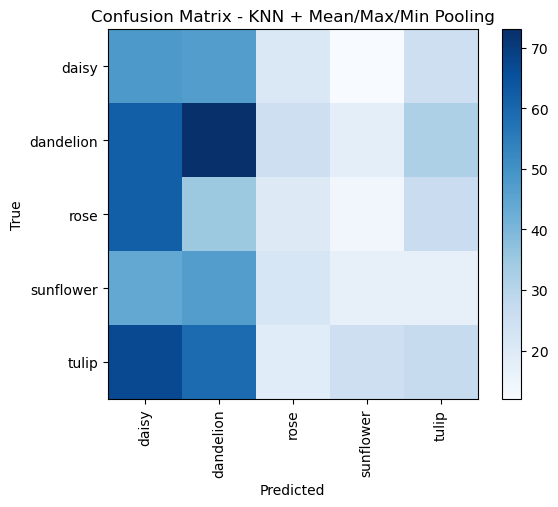

In [3]:
# using min pooling only
features = np.array(min_pools, dtype=np.float32)
print("Feature matrix shape:", features.shape)

# Normalize features (optional but helps distance metrics)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, labels, test_size=TEST_SIZE, stratify=labels, random_state=RANDOM_STATE
)

# KNN classifier
knn = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS, metric='euclidean')
knn.fit(X_train, y_train)

# Evaluate
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy (Mean+Max+Min pooling): {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - KNN + Mean/Max/Min Pooling")
plt.colorbar()
plt.xticks(np.arange(len(classes)), classes, rotation=90)
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Feature matrix shape: (4317, 128)
KNN Accuracy (Mean+Max+Min pooling): 0.4479
              precision    recall  f1-score   support

       daisy       0.34      0.48      0.40       153
   dandelion       0.59      0.56      0.58       210
        rose       0.39      0.39      0.39       157
   sunflower       0.50      0.49      0.49       147
       tulip       0.43      0.31      0.36       197

    accuracy                           0.45       864
   macro avg       0.45      0.45      0.44       864
weighted avg       0.46      0.45      0.45       864



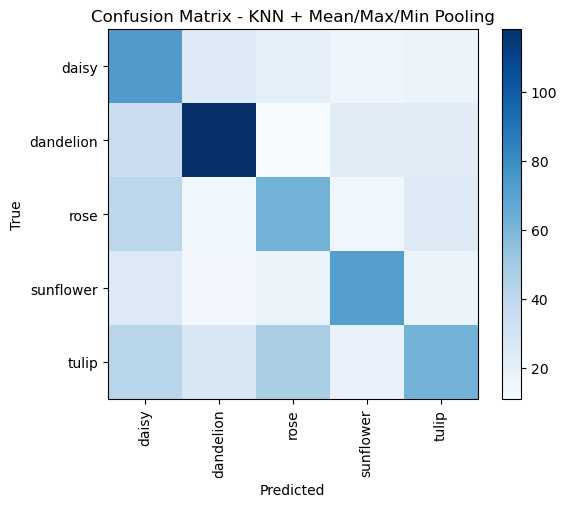

In [4]:
# using mean pooling only
features = np.array(mean_pools, dtype=np.float32)
print("Feature matrix shape:", features.shape)

# Normalize features (optional but helps distance metrics)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    features_scaled, labels, test_size=TEST_SIZE, stratify=labels, random_state=RANDOM_STATE
)

# KNN classifier
knn = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS, metric='euclidean')
knn.fit(X_train, y_train)

# Evaluate
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy (Mean+Max+Min pooling): {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=classes))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - KNN + Mean/Max/Min Pooling")
plt.colorbar()
plt.xticks(np.arange(len(classes)), classes, rotation=90)
plt.yticks(np.arange(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()